In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from typing import Dict, Any, Optional, List

plt.style.use("ggplot")

In [2]:
os.getcwd()

'/home/jterryc/KOMOREBI-PROJECT/notebooks'

In [3]:
os.listdir(".")

['EDA_jtc.md',
 'EDA_jtc_old.ipynb',
 'EDA_jtc.ipynb',
 'notebooks.txt',
 'EDA_jon.ipynb',
 'EDA_jtc_files']

In [4]:
wd_local_path = '../data/zrive_advertiser_withdrawals.parquet'
dim_local_path = '../data/zrive_dim_advertiser.parquet'
fct_local_path = '../data/zrive_fct_monthly_snapshot_advertiser.parquet'

In [151]:
df_wd = pd.read_parquet(wd_local_path, engine='fastparquet')
df_dim = pd.read_parquet(dim_local_path, engine='fastparquet')


### Witdrawals

In [152]:
df_wd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22668 entries, 0 to 22667
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   withdrawal_id              22668 non-null  int64         
 1   advertiser_zrive_id        22668 non-null  int64         
 2   withdrawal_status          22668 non-null  object        
 3   withdrawal_type            22668 non-null  object        
 4   withdrawal_creation_date   22668 non-null  datetime64[us]
 5   withdrawal_effective_date  14348 non-null  datetime64[ns]
 6   withdrawal_reason          22668 non-null  object        
dtypes: datetime64[ns](1), datetime64[us](1), int64(2), object(3)
memory usage: 1.2+ MB


In [153]:
df_wd.isna().sum()

withdrawal_id                   0
advertiser_zrive_id             0
withdrawal_status               0
withdrawal_type                 0
withdrawal_creation_date        0
withdrawal_effective_date    8320
withdrawal_reason               0
dtype: int64

In [154]:
df_wd.shape

(22668, 7)

In [155]:
def print_unique(df: pd.DataFrame, column: str = None):
    if column is None:
        for col in df.columns:
            if df[col].dtype == object:
                print(f"- {col} ({df[col].nunique()}): {df[col].unique()}")
    else:
        print(f"- {column} ({df[column].nunique()}): {df[column].unique()}")

print_unique(df_wd)

- withdrawal_status (3): ['Cerrada' 'Denegada' 'Pendiente Administración']
- withdrawal_type (2): ['TOTAL' 'PARCIAL']
- withdrawal_reason (18): ['RESULTADOS' 'FALTA DE USO/TIEMPO' 'RAZONES ECONOMICAS' 'MOROSIDAD'
 'RATIO RESULTADO-INVERSION' 'OTROS' 'FALTA DE PRODUCTO'
 'CESE DE ACTIVIDAD' 'FIN DE CONTRATO' 'Cambio a Bundle Online'
 'Baja Bundle AS24' 'Upselling-cambio de contrato' 'No acepta subida'
 'CORONAVIRUS' 'Cambio de Contrato/propuesta/producto'
 'Incidencias de la web' 'Reestructuración cuentas de grupo' 'Desconocido']


In [156]:
withdrawal_reason_not = ['Upselling-cambio de contrato', 'Cambio a Bundle Online','Cambio de Contrato/propuesta/producto']
# withdrawal_reason_yes = [reason for reason in df_wd.withdrawal_reason.unique() if reason not in withdrawal_reason_not]
withdrawal_reason_yes = set(df_wd.withdrawal_reason.values).difference(set(withdrawal_reason_not))
withdrawal_reason_yes

{'Baja Bundle AS24',
 'CESE DE ACTIVIDAD',
 'CORONAVIRUS',
 'Desconocido',
 'FALTA DE PRODUCTO',
 'FALTA DE USO/TIEMPO',
 'FIN DE CONTRATO',
 'Incidencias de la web',
 'MOROSIDAD',
 'No acepta subida',
 'OTROS',
 'RATIO RESULTADO-INVERSION',
 'RAZONES ECONOMICAS',
 'RESULTADOS',
 'Reestructuración cuentas de grupo'}

In [157]:
withdrawal_reason_yes = set(df_wd.withdrawal_reason.values).difference(set(withdrawal_reason_not))

In [158]:
df_wd["is_definitive_withdrawal"] = (
    df_wd.withdrawal_reason.isin(withdrawal_reason_yes) &
    (df_wd.withdrawal_type == "TOTAL") &
    (df_wd.withdrawal_status != "Denegada")
).astype(int)
df_wd

,withdrawal_id,advertiser_zrive_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal
0,0,259,Cerrada,TOTAL,2012-06-19 07:12:34,2012-07-01,RESULTADOS,1
1,1,221,Cerrada,TOTAL,2012-06-19 07:16:34,NaT,RESULTADOS,1
2,7,492,Cerrada,TOTAL,2012-06-20 07:10:16,2012-07-01,RESULTADOS,1
3,12,481,Cerrada,TOTAL,2012-06-20 11:59:36,2012-07-01,RESULTADOS,1
4,16,457,Cerrada,TOTAL,2012-06-20 15:41:39,2012-07-01,FALTA DE USO/TIEMPO,1
...,...,...,...,...,...,...,...,...
22663,55613,684,Cerrada,TOTAL,2025-05-30 10:57:08,2025-08-01,RATIO RESULTADO-INVERSION,1
22664,55614,251,Cerrada,TOTAL,2025-05-30 10:58:12,2025-08-01,RATIO RESULTADO-INVERSION,1
22665,55615,80,Cerrada,TOTAL,2025-05-30 10:59:03,2025-08-01,RATIO RESULTADO-INVERSION,1
22666,55616,5149,Cerrada,TOTAL,2025-05-30 11:15:01,2025-07-01,MOROSIDAD,1


In [159]:
df_wd[df_wd.is_definitive_withdrawal == 1].withdrawal_reason.value_counts()

withdrawal_reason
RESULTADOS                           5761
MOROSIDAD                            3178
RAZONES ECONOMICAS                   2241
RATIO RESULTADO-INVERSION            1620
FALTA DE USO/TIEMPO                   852
OTROS                                 717
FALTA DE PRODUCTO                     573
CESE DE ACTIVIDAD                     456
Reestructuración cuentas de grupo     184
FIN DE CONTRATO                       144
CORONAVIRUS                           101
No acepta subida                       51
Desconocido                            36
Incidencias de la web                  21
Baja Bundle AS24                        6
Name: count, dtype: int64

In [160]:
df_wd.is_definitive_withdrawal.value_counts()

is_definitive_withdrawal
1    15941
0     6727
Name: count, dtype: int64

In [161]:
df_wd.advertiser_zrive_id.value_counts()

advertiser_zrive_id
122     58
2915    47
1378    44
953     36
56      35
        ..
6927     1
6294     1
6409     1
6825     1
6922     1
Name: count, Length: 6021, dtype: int64

In [162]:
real_withdrawal_pct = df_wd[df_wd["is_definitive_withdrawal"] == 1].shape[0]/df_wd.shape[0]
real_withdrawal_pct

0.7032380448208929

Si se consideran bajas definitivas aquellas donde se cumplen estas 3 condiciones simultáneamente:
1. withdrawal_type = 'TOTAL'
2. withdrawal_status != 'Denegada'
3. withdrawal_reason not in ('Upselling-cambio de contrato', 'Cambio a Bundle Online',
'Cambio de Contrato/propuesta/producto')

Obtenemos que el 70.71% de registros de posibles abandonos fueron abandonos definitivos

Pregunta: a partir de ahora, ¿nos importa el df sólo cuando is_permanent_withdrawal = 1, o con ambos casos posibles?

In [17]:
df_wd.isnull().sum()

withdrawal_id                   0
advertiser_zrive_id             0
withdrawal_status               0
withdrawal_type                 0
withdrawal_creation_date        0
withdrawal_effective_date    8320
withdrawal_reason               0
is_definitive_withdrawal        0
dtype: int64

withdrawal_status
Cerrada                     0.999735
Denegada                    0.000176
Pendiente Administración    0.000088
Name: proportion, dtype: float64


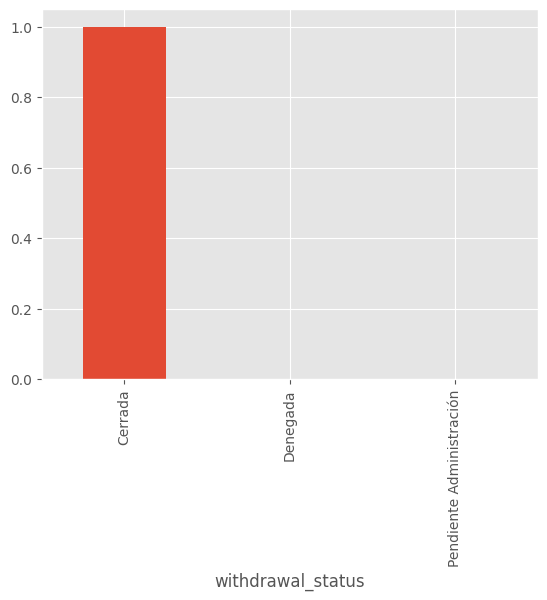

In [18]:
df_wd.withdrawal_status.value_counts(normalize=True).plot(kind='bar')
print(df_wd.withdrawal_status.value_counts(normalize=True))

Pregunta: predomina la categoría "Cerrada" con casi un 99.99%. ¿Habría que eliminarla? Entiendo que no da mucha información ya que el dataset de por sí son los casos en los que la salida del cliente fue definitiva, con lo cual el estado de de "withdrawal" no tiene mucha relevancia aquí

<Axes: xlabel='is_definitive_withdrawal'>

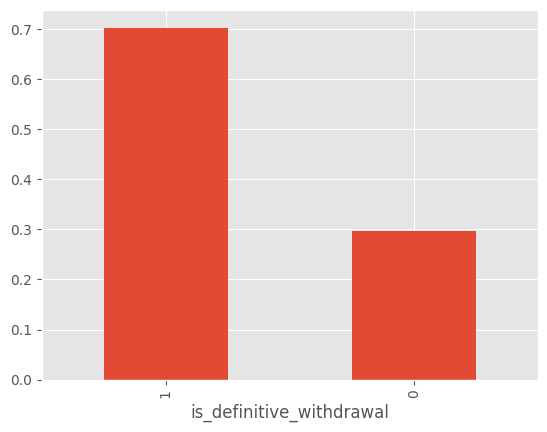

In [19]:
df_wd.is_definitive_withdrawal.value_counts(normalize=True).plot(kind="bar")

### Bajas definitivas

Para un mismo usuario, ¿hay múltiples bajas defitivas (is_definitive_withdrawal == 1)? A continuación comprobamos que sí

In [20]:
(
    df_wd
    .groupby("advertiser_zrive_id")["is_definitive_withdrawal"]
    .sum()
    .loc[lambda x: x > 1]
)

advertiser_zrive_id
1       2
2       4
4       4
5       5
6       9
       ..
6800    2
6815    2
6866    2
6878    2
6907    2
Name: is_definitive_withdrawal, Length: 3245, dtype: int64

In [21]:
df_wd[df_wd["advertiser_zrive_id"] == 259]

,withdrawal_id,advertiser_zrive_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal
0,0,259,Cerrada,TOTAL,2012-06-19 07:12:34,2012-07-01,RESULTADOS,1
182,1035,259,Cerrada,TOTAL,2013-02-26 09:05:09,2013-03-01,OTROS,1
184,1040,259,Cerrada,TOTAL,2013-02-27 08:07:40,NaT,OTROS,1
273,1462,259,Cerrada,TOTAL,2013-06-06 07:38:53,NaT,RESULTADOS,1
279,1484,259,Cerrada,TOTAL,2013-06-11 15:55:25,NaT,RESULTADOS,1
351,1907,259,Cerrada,TOTAL,2013-09-09 08:34:25,NaT,RESULTADOS,1
772,3949,259,Cerrada,TOTAL,2014-08-05 09:18:11,2014-09-01,RESULTADOS,1
1622,14633,259,Cerrada,TOTAL,2016-03-16 16:34:27,2016-05-01,RESULTADOS,1
2009,17386,259,Cerrada,TOTAL,2016-11-10 07:55:40,NaT,RESULTADOS,1
2276,18481,259,Cerrada,PARCIAL,2017-02-27 21:21:44,2017-03-01,RESULTADOS,0


In [165]:
wd_reason = df_wd[df_wd["is_definitive_withdrawal"] == 1].copy()
wd_reason["withdrawal_reason"].value_counts(normalize=True)*100

withdrawal_reason
RESULTADOS                           36.139514
MOROSIDAD                            19.936014
RAZONES ECONOMICAS                   14.058089
RATIO RESULTADO-INVERSION            10.162474
FALTA DE USO/TIEMPO                   5.344709
OTROS                                 4.497836
FALTA DE PRODUCTO                     3.594505
CESE DE ACTIVIDAD                     2.860548
Reestructuración cuentas de grupo     1.154256
FIN DE CONTRATO                       0.903331
CORONAVIRUS                           0.633586
No acepta subida                      0.319930
Desconocido                           0.225833
Incidencias de la web                 0.131736
Baja Bundle AS24                      0.037639
Name: proportion, dtype: float64

### Dim Advertiser

Contiene información general y descriptiva de los anunciantes de la plataforma.

- 🔑 **advertiser_zive_id**: Identificador único del anunciante.
- **province_id**: Identificador de la provincia del anunciante.
- **advertiser_province**: Nombre de la provincia del anunciante.
- **updated_at**: Fecha y hora de la última actualización de los datos del anunciante.
- **advertiser_group_id**: Identificador del grupo al que pertenece el anunciante, en caso de formar parte de uno.
- **min_start_contrato_date**: Fecha de inicio del primer contrato del anunciante (antigüedad en la plataforma).
- **max_start_contrato_nuevo_date**: Fecha de inicio del último contrato de tipo *nuevo*, si existe. Indica si el anunciante se dio de baja y posteriormente regresó a la plataforma.
- **contrato_churn_date**: Fecha de finalización del último contrato.  
  - Si es **nula**, el anunciante tiene un contrato activo sin fecha de finalización especificada.  
  - Si es **futura**, no implica necesariamente una baja, ya que el contrato puede renovarse automáticamente.

Pregunta: ¿**contrato_churn_date** es futura con respecto a qué? Creo que respecto al period_int (mes de la tabla fct, que es la foto "actual") 



In [22]:
df_dim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7076 entries, 0 to 7075
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   advertiser_zrive_id            7076 non-null   int64         
 1   province_id                    7076 non-null   int64         
 2   updated_at                     7076 non-null   datetime64[us]
 3   advertiser_province            7076 non-null   object        
 4   advertiser_group_id            1323 non-null   float64       
 5   min_start_contrato_date        7076 non-null   datetime64[ns]
 6   max_start_contrato_nuevo_date  5208 non-null   datetime64[ns]
 7   contrato_churn_date            3894 non-null   datetime64[ns]
dtypes: datetime64[ns](3), datetime64[us](1), float64(1), int64(2), object(1)
memory usage: 442.4+ KB


In [23]:
print_unique(df_dim)

- advertiser_province (52): ['Álava' 'Albacete' 'Alicante' 'Asturias' 'Badajoz' 'Barcelona' 'Burgos'
 'Cáceres' 'Cantabria' 'Castellón' 'Córdoba' 'La Coruña' 'Girona'
 'Granada' 'Guadalajara' 'Huesca' 'Islas Baleares' 'Jaén' 'Lugo' 'Madrid'
 'Málaga' 'Murcia' 'Navarra' 'Pontevedra' 'La Rioja' 'Segovia' 'Sevilla'
 'Teruel' 'Toledo' 'Valencia' 'Valladolid' 'Vizcaya' 'Zaragoza' 'Almería'
 'Ávila' 'Cádiz' 'Ciudad Real' 'Cuenca' 'Guipúzcoa' 'Huelva' 'León'
 'Lleida' 'Orense' 'Palencia' 'Las Palmas' 'Salamanca' 'Soria' 'Tarragona'
 'Tenerife' 'Zamora' 'Ceuta' 'Melilla']


In [24]:
df_dim.isnull().sum()

advertiser_zrive_id                 0
province_id                         0
updated_at                          0
advertiser_province                 0
advertiser_group_id              5753
min_start_contrato_date             0
max_start_contrato_nuevo_date    1868
contrato_churn_date              3182
dtype: int64

Missing values:
- **advertiser_group_id** indica el grupo al que pertenece el anunciante, (Pregunta) ¿esta información es relevante? Hay anunciantes que no pertenecen a ningun grupo
- **max_start_contrato_nuevo_date** indica la fecha en la que un anunciante que se había dado de baja, se volivó a dar de alta. Tiene sentido que haya valores nulos por que habrá casos en los que el anunciante se dió de baja y no volvió. Una cuestión interesante es ver con qué precio se dió de alta tanto la primera como la segunda vez
- **contrato_churn_date** indica la fecha final del último contrato. 

Pregunta: ¿Los valores nulos indican que el contrato está activo?

In [25]:
df_dim.max_start_contrato_nuevo_date.isna().sum()/df_dim.shape[0]

np.float64(0.2639909553420011)

In [26]:
df_dim.min_start_contrato_date.value_counts()

min_start_contrato_date
2024-12-19    62
2024-06-05    61
2024-12-18    51
2022-01-12    38
2024-06-03    31
              ..
2019-05-22     1
2018-10-05     1
2019-02-18     1
2019-04-29     1
2020-10-16     1
Name: count, Length: 1391, dtype: int64

In [27]:
df_dim.min_start_contrato_date.dt.to_period("Y").value_counts()

min_start_contrato_date
2022    2018
2023    1642
2024    1582
2021     644
2025     504
2020     488
2019     136
2017      14
2016      13
2018      12
2013       8
2014       7
2009       3
2011       2
2015       2
2010       1
Freq: Y-DEC, Name: count, dtype: int64

In [28]:
n_active_contracts = df_dim[df_dim["contrato_churn_date"].isna()]
n_active_contracts

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date
98,1405,1,2025-06-06 09:54:13,Álava,191.0,2020-04-07,NaT,NaT
99,614,1,2025-06-17 13:13:47,Álava,193.0,2022-10-20,2024-02-21,NaT
100,487,1,2024-11-11 13:56:58,Álava,NaN,2023-11-21,2023-11-21,NaT
101,2861,1,2024-08-08 12:14:49,Álava,190.0,2020-04-28,2024-02-28,NaT
102,6703,1,2025-05-19 08:42:47,Álava,125.0,2024-12-20,2024-12-20,NaT
...,...,...,...,...,...,...,...,...
3275,5499,50,2025-02-21 09:12:19,Zaragoza,NaN,2023-10-10,2023-10-10,NaT
3276,2665,50,2024-01-12 15:31:17,Zaragoza,48.0,2020-03-16,NaT,NaT
3277,7073,50,2025-06-17 17:03:47,Zaragoza,NaN,2025-06-17,2025-06-17,NaT
3278,492,50,2025-01-14 12:33:40,Zaragoza,163.0,2022-04-08,NaT,NaT


In [29]:
n_active_contracts.shape[0]/df_dim.shape[0]

0.44968908988128886

Casi el 45% de los contratos están activos a día de hoy

<Axes: xlabel='advertiser_province'>

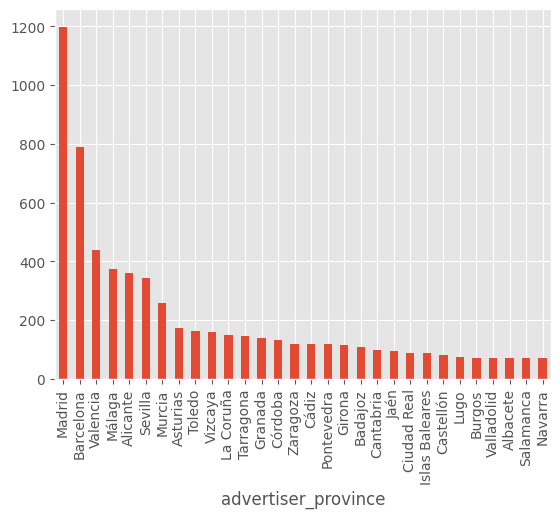

In [30]:
(
    df_dim
    .groupby('advertiser_province')["advertiser_zrive_id"]
    .count()
    .sort_values(ascending=False)
    .head(30)
).plot(kind='bar')

**Outliers**:
- Pocas provincias concentran muchísimos anunciantes 
- Gran mayoría de provincias tienen pocos anunciantes

Pregunta: ¿Debemos transformar esta variable para tratar los outliers?

In [31]:
df_dim.iloc[7072]

advertiser_zrive_id                              789
province_id                                       48
updated_at                       2025-04-30 13:40:11
advertiser_province                          Vizcaya
advertiser_group_id                              NaN
min_start_contrato_date          2022-10-01 00:00:00
max_start_contrato_nuevo_date    2025-01-30 00:00:00
contrato_churn_date              2025-06-30 00:00:00
Name: 7072, dtype: object

Por ejemplo este anunciante:
- Se dió de alta por primera vez el 2022-10-01
- Se volvió a dar de alta el 2025-01-30
- Se dió de baja el 2025-06-30 (Pregunta: ¿sabemos si se fue antes de que se le acabara el contrato? ¿hay que distinguir entre si se le acabó el contrato y no renovó y si abandonó antes de lo previsto? ¿O ambas casuísticas se tratan igual?)

### FCT

Métricas mensuales relacionadas con el desempeño de los anunciantes.

#### Identificadores
- 🔑 **advertiser_zive_id**: Identificador único del anunciante.
- 🔑 **period_int**: Identificador del mes en formato `YYYYMM`.

#### Métricas de anuncios
- **monthly_contracted_ads**: Número total de anuncios contratados.
- **monthly_published_ads**: Número total de anuncios publicados.
- **monthly_unique_published_ads**: Número total de anuncios únicos publicados, en caso de publicar anuncios en diferentes provincias.
- **monthly_distinct_ads**: Número total de anuncios diferentes publicados en un mes (rotación total mensual).

#### Anuncios premium
- **monthly_oro_ads**: Número total de anuncios Oro contratados.
- **monthly_plata_ads**: Número total de anuncios Plata contratados.
- **monthly_destacados_ads**: Número total de anuncios Destacados contratados.
- **monthly_pepitas_ads**: Número total de anuncios Pepitas contratados.

#### Métricas de interacción
- **monthly_shows_ads**: Número total de búsquedas de anuncios publicados.
- **monthly_visits_ads**: Número total de visitas de anuncios publicados.
- **monthly_leads**: Número total de leads de anuncios publicados.
- **monthly_total_phone_views**: Número total de vistas del teléfono del anunciante de anuncios publicados.
- **monthly_total_calls**: Número total de llamadas al anunciante de anuncios publicados.
- **monthly_total_emails**: Número total de emails al anunciante de anuncios publicados.

#### Métricas económicas
- **monthly_total_invoice**: Facturación mensual.
- **monthly_total_reference_price**: Precio tarifa mensual.
- **monthly_avg_ad_price**: Precio medio de los anuncios publicados.

#### Métricas únicas
- **monthly_unique_calls**: Número de llamadas al anunciante de anuncios únicos publicados.
- **monthly_unique_emails**: Número de emails al anunciante de anuncios únicos publicados.
- **monthly_unique_leads**: Número de leads de anuncios únicos publicados.

#### Estado del contrato
- **has_active_contract**: Indica si el anunciante tiene una propuesta activa en el mes.



In [32]:
df_fct = pd.read_parquet(fct_local_path, engine='fastparquet')

In [33]:
df_fct.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96829 entries, 0 to 96828
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   advertiser_zrive_id            96829 non-null  int64  
 1   period_int                     96829 non-null  int64  
 2   monthly_contracted_ads         96829 non-null  int64  
 3   monthly_published_ads          96829 non-null  int64  
 4   monthly_unique_published_ads   96829 non-null  int64  
 5   monthly_distinct_ads           86777 non-null  float64
 6   monthly_oro_ads                96829 non-null  int64  
 7   monthly_plata_ads              96829 non-null  int64  
 8   monthly_destacados_ads         96829 non-null  int64  
 9   monthly_pepitas_ads            96829 non-null  int64  
 10  monthly_shows                  96829 non-null  float64
 11  monthly_visits                 96829 non-null  float64
 12  monthly_leads                  96829 non-null 

In [34]:
df_fct.head()

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
0,1,202301,75,47,47,56.0,6,6,6,0,...,14,15,0,1714.2,2416.7,12,3,15,42667.86,True
1,2,202301,150,31,31,55.0,10,10,4,0,...,16,2,2,293.3,3643.3,2,2,4,22742.40,True
2,3,202301,0,0,0,NaN,0,0,0,0,...,0,0,0,0.0,NaN,0,0,0,25420.83,False
3,4,202301,85,79,79,86.0,3,3,1,0,...,10,8,2,1165.0,3023.3,6,6,12,23259.52,True
4,6,202301,20,20,20,25.0,0,0,1,0,...,10,4,3,336.3,515.0,4,11,15,43439.00,True


In [35]:
try:
    df_fct["period_int"] = pd.to_datetime(df_fct['period_int'].astype(str), format="%Y%m")
except ValueError:
    pass
df_fct.head()

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
0,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,14,15,0,1714.2,2416.7,12,3,15,42667.86,True
1,2,2023-01-01,150,31,31,55.0,10,10,4,0,...,16,2,2,293.3,3643.3,2,2,4,22742.40,True
2,3,2023-01-01,0,0,0,NaN,0,0,0,0,...,0,0,0,0.0,NaN,0,0,0,25420.83,False
3,4,2023-01-01,85,79,79,86.0,3,3,1,0,...,10,8,2,1165.0,3023.3,6,6,12,23259.52,True
4,6,2023-01-01,20,20,20,25.0,0,0,1,0,...,10,4,3,336.3,515.0,4,11,15,43439.00,True


In [36]:
df_fct.isnull().sum()

advertiser_zrive_id                  0
period_int                           0
monthly_contracted_ads               0
monthly_published_ads                0
monthly_unique_published_ads         0
monthly_distinct_ads             10052
monthly_oro_ads                      0
monthly_plata_ads                    0
monthly_destacados_ads               0
monthly_pepitas_ads                  0
monthly_shows                        0
monthly_visits                       0
monthly_leads                        0
monthly_total_phone_views            0
monthly_total_calls                  0
monthly_total_emails                 0
monthly_total_invoice                0
monthly_total_reference_price    12330
monthly_unique_calls                 0
monthly_unique_emails                0
monthly_unique_leads                 0
monthly_avg_ad_price              8467
has_active_contract                  0
dtype: int64

In [37]:
df_fct.head()

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
0,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,14,15,0,1714.2,2416.7,12,3,15,42667.86,True
1,2,2023-01-01,150,31,31,55.0,10,10,4,0,...,16,2,2,293.3,3643.3,2,2,4,22742.40,True
2,3,2023-01-01,0,0,0,NaN,0,0,0,0,...,0,0,0,0.0,NaN,0,0,0,25420.83,False
3,4,2023-01-01,85,79,79,86.0,3,3,1,0,...,10,8,2,1165.0,3023.3,6,6,12,23259.52,True
4,6,2023-01-01,20,20,20,25.0,0,0,1,0,...,10,4,3,336.3,515.0,4,11,15,43439.00,True


In [38]:
df_fct["advertiser_zrive_id"].nunique()

6968

En la base de datos tenemos información de **6968** anunciantes distintos

In [39]:
df_dim["advertiser_zrive_id"].nunique()

7076

In [40]:
ids_df1 = set(df_fct['advertiser_zrive_id'])
ids_df2 = set(df_dim['advertiser_zrive_id'])

solo_en_df1 = ids_df1 - ids_df2
solo_en_df2 = ids_df2 - ids_df1

df_dim[df_dim['advertiser_zrive_id'].isin(solo_en_df2)]


,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date
12,3388,5,2022-10-28 13:28:56,Asturias,NaN,2024-03-11,NaT,2024-03-15
16,4095,8,2022-10-07 09:43:18,Barcelona,NaN,2022-07-01,NaT,2024-06-27
27,1178,9,2019-12-28 20:14:49,Burgos,120.0,2020-02-05,2020-02-05,2024-12-26
201,7070,3,2025-06-11 15:42:23,Alicante,NaN,2025-06-11,2025-06-11,NaT
240,6918,3,2025-06-18 13:01:44,Alicante,NaN,2025-06-11,2025-06-11,NaT
...,...,...,...,...,...,...,...,...
6633,1800,9,2019-12-28 19:59:58,Burgos,120.0,2024-07-29,2024-07-29,2025-03-31
6642,2662,12,2021-01-21 12:17:37,Cantabria,NaN,2024-06-07,2024-06-07,2025-03-31
6708,545,30,2021-01-21 12:21:40,Málaga,NaN,2024-06-03,2024-06-03,2025-03-31
7009,2351,40,2022-10-28 10:07:04,Sevilla,NaN,2020-11-11,2020-11-11,2025-05-31


In [41]:
df_dim.advertiser_group_id.nunique()

112

Hay 112 grupos de anunciantes

<Axes: title={'center': 'Top 10 grupos con más anunciantes'}, xlabel='advertiser_group_id'>

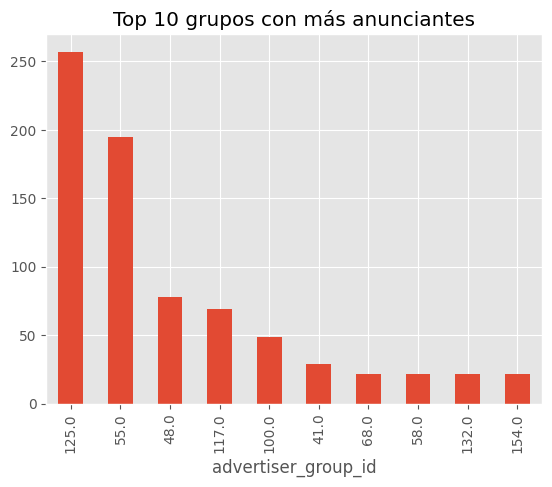

In [42]:
advertiser_groups = (
    df_dim
    .groupby("advertiser_group_id")["advertiser_zrive_id"]
    .nunique()
    .sort_values(ascending=False)
)
advertiser_groups.head(10).plot(kind='bar', title="Top 10 grupos con más anunciantes")

In [43]:
advertiser_groups.describe()

count    112.000000
mean      11.812500
std       31.438924
min        1.000000
25%        2.000000
50%        4.000000
75%       11.000000
max      257.000000
Name: advertiser_zrive_id, dtype: float64

<Axes: xlabel='monthly_total_invoice', ylabel='n_months'>

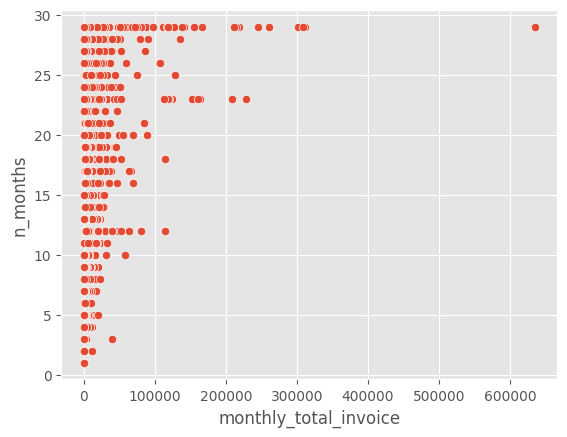

In [44]:
months = df_fct.groupby("advertiser_zrive_id")["period_int"].nunique()

df_clients = df_fct.groupby("advertiser_zrive_id").agg({
    "monthly_total_invoice": "sum",
    "monthly_contracted_ads": "median"
}).join(months.rename("n_months"))

import seaborn as sns
sns.scatterplot(data=df_clients, x="monthly_total_invoice", y="n_months")

#### Merge 

Hacemos un left join en **Zrive_fct_monthly_snapshot_advertiser (df_fct)** para tener la foto completa con la información de **Zrive_dim_advertiser (df_dim)**

In [45]:
df_fct_merged = df_fct.merge(right=df_dim, how='left', on='advertiser_zrive_id')

<Axes: title={'center': 'Usuarios con grupo vs. individuales'}, xlabel='advertiser_group_id'>

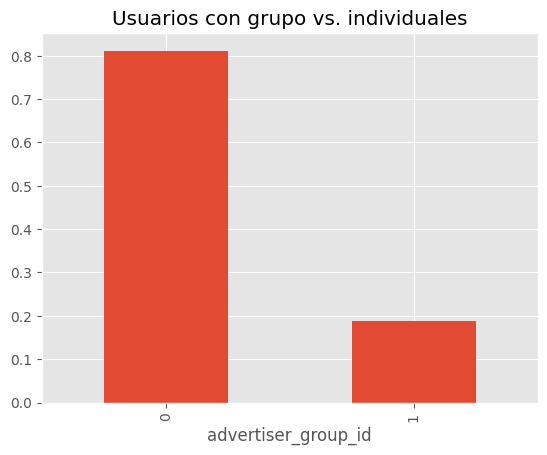

In [46]:
# Proporción de anunciantes pertenecientes a un grupo y anunciantes individuales

advertiser_group_proportion = (
    df_fct_merged
    .groupby("advertiser_zrive_id")["advertiser_group_id"]
    .nunique()
)

advertiser_group_proportion.value_counts(normalize=True).plot(kind='bar', title="Usuarios con grupo vs. individuales")

In [47]:
print(f"% advertisers pertenecientes a grupos: {advertiser_group_proportion.value_counts()[0]/advertiser_group_proportion.shape[0]:.4f}")
print(f"% advertisers pertenecientes a grupos: {advertiser_group_proportion.value_counts()[1]/advertiser_group_proportion.shape[0]:.4f}")

% advertisers pertenecientes a grupos: 0.8117
% advertisers pertenecientes a grupos: 0.1883


In [48]:
advertiser_group_proportion.value_counts()[0]

np.int64(5656)

In [49]:
print(df_fct_merged["period_int"].min())
print(df_fct_merged["period_int"].max())

2023-01-01 00:00:00
2025-05-01 00:00:00


El período del que se tienen datos va desde el 2023-01 hasta 2025-05

In [50]:
df_fct_merged.head()

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_unique_leads,monthly_avg_ad_price,has_active_contract,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date
0,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,15,42667.86,True,11,2023-06-16 09:35:01,Cádiz,NaN,2020-12-23,NaT,2023-05-31
1,2,2023-01-01,150,31,31,55.0,10,10,4,0,...,4,22742.40,True,11,2023-11-06 16:01:14,Cádiz,100.0,2020-09-25,2020-09-25,NaT
2,3,2023-01-01,0,0,0,NaN,0,0,0,0,...,0,25420.83,False,8,2024-08-07 13:37:09,Barcelona,41.0,2024-05-06,NaT,2024-07-15
3,4,2023-01-01,85,79,79,86.0,3,3,1,0,...,12,23259.52,True,48,2023-05-03 16:37:02,Vizcaya,NaN,2022-09-30,NaT,NaT
4,6,2023-01-01,20,20,20,25.0,0,0,1,0,...,15,43439.00,True,48,2025-03-12 13:48:02,Vizcaya,NaN,2022-10-10,NaT,NaT


### Análisis permanencia por anunciante

In [51]:
df_months = (
    df_fct
    .groupby("advertiser_zrive_id")["period_int"]
    .nunique()
    .reset_index()
    .rename(columns={"period_int":"n_months"})
)

print(df_months["n_months"].describe())

count    6968.000000
mean       13.896240
std         9.970446
min         1.000000
25%         5.000000
50%        11.000000
75%        25.000000
max        29.000000
Name: n_months, dtype: float64


Text(0, 0.5, 'Anunciantes')

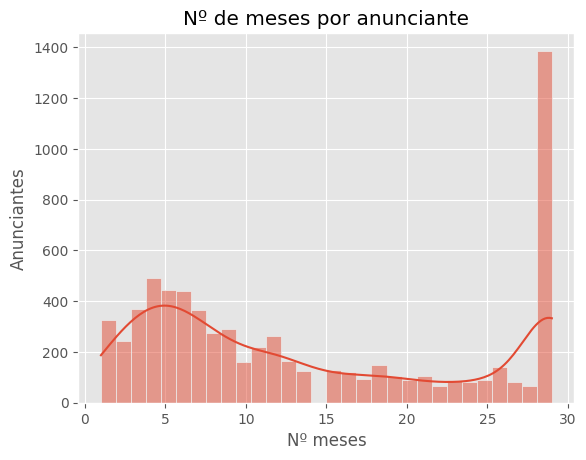

In [52]:
sns.histplot(df_months, x="n_months", bins=30, kde=True)

plt.title("Nº de meses por anunciante")
plt.xlabel("Nº meses")
plt.ylabel("Anunciantes")

Text(0.5, 1.0, 'Distribución de n_months')

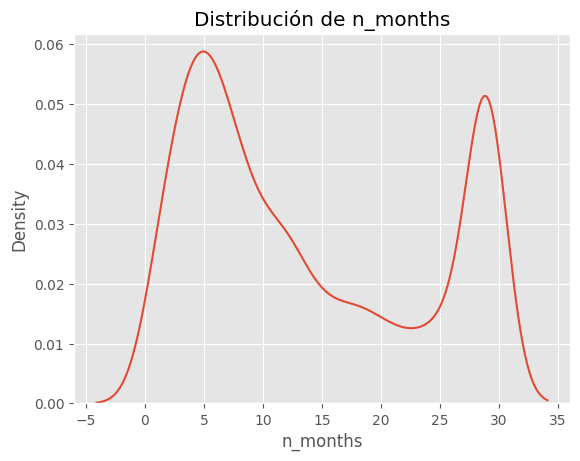

In [53]:
sns.kdeplot(df_months["n_months"])
plt.title("Distribución de n_months")

Distribución bimodal; podemos comprobar que los advertisers se concentran en dos grupos principales:
- Corto-medio plazo (5 meses aprox.)
- Largo plazo (29 meses aprox.)

Text(0.5, 1.0, 'Distribución de n_months < 29')

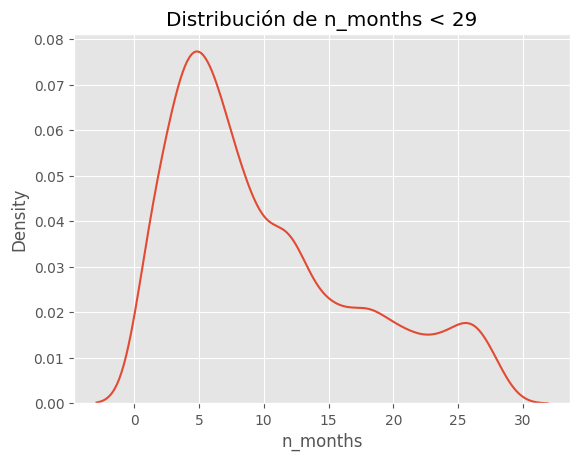

In [54]:
sns.kdeplot(df_months[df_months["n_months"] < 29]["n_months"])
plt.title("Distribución de n_months < 29")

In [55]:
df_months[df_months["n_months"] == 29].count()

advertiser_zrive_id    1387
n_months               1387
dtype: int64

In [56]:
long_term_adv_pct = len(df_months[df_months["n_months"] == 29])/len(df_months)*100
round(long_term_adv_pct,2)

19.91

De aquí podemos sacar insights:
- Los anunciantes permanecen en la plataforma una media de 13.9 meses
- Ditribución bimodal; dos poblaciones: 
    - Anunciantes corto-medio plazo, muchos se concentran a la izquierda, permaneciendo pocos meses activos (5 meses en promedio)
    - Anunciantes largo plazo: un total de **1387** anunciantes (casi un 20%) permanecieron el periodo completo (29 meses)
- Si quitamos anunciantes que permanecieron 29 meses, obtenemos la gráfica anterior

### Análisis **estabilidad**

Cliente estable: más de 3 o más meses en la plataforma

count    6968.000000
mean        0.918054
std         0.274302
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: is_stable, dtype: float64


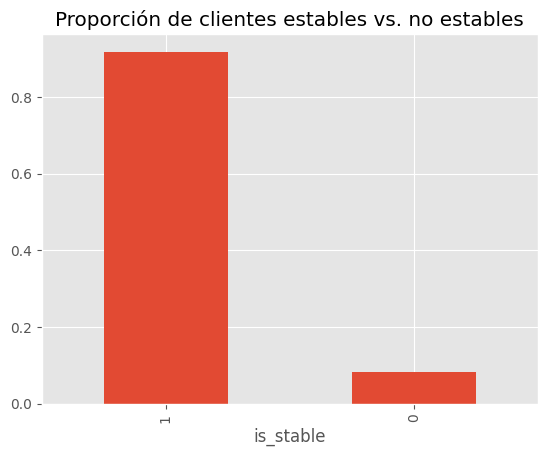

In [57]:
df_advertiser = (
    df_fct.groupby("advertiser_zrive_id")["period_int"]
    .nunique()
    .reset_index()
    .assign(is_stable=lambda df: (df["period_int"] >= 3).astype(int))
)
df_advertiser.is_stable.value_counts(normalize=True).plot(kind='bar')
plt.title("Proporción de clientes estables vs. no estables")

print(df_advertiser.is_stable.describe())

Si definimos un cliente **no estable** como un cliente que permaneció en la plataforma **menos de 3 meses**, obtenemos esta gráfica que representa la distribución de clientes por estabilidad.
Observamos que está bastante desbalanceada, es decir, la mayoría de advertisers permanecieron más de 3 meses

### Análisis de los clientes **No Estables**

In [58]:
unstable_ids = df_advertiser.loc[df_advertiser["is_stable"] == 0, "advertiser_zrive_id"]

Ejemplo: usuario 142
- No estable: period_int únicos = 1 (solo permaneció 1 mes)
- Tiene 6 withdrawal_id diferentes: solicitó la baja en **6 ocasiones**
- Se dió de baja definitivamente ("is_definite_withdrawal") **5 veces**


In [59]:
dim_users = set(df_dim.advertiser_zrive_id.unique())
fct_users = set(df_fct.advertiser_zrive_id.unique())

len(dim_users - fct_users)

108

In [60]:
df_fct.advertiser_zrive_id.nunique()

6968

## **Cálculo nº días de permanencia**

Sabemos que un usuario es churn si:
1. withdrawal_type = 'TOTAL'
2. withdrawal_status != 'Denegada'
3. withdrawal_reason not in ('Upselling-cambio de contrato', 'Cambio a Bundle Online',
'Cambio de Contrato/propuesta/producto')

Por otro lado, de la tabla **zrive_dim_advertiser** tenemos los siguientes datos:
- **min_start_contrato_date**: primera: fecha inicio primer contrato (nuevo contrato)
- **max_start_contrato_nuevo_date**: última fecha de inicio de nuevo contrato
- **contrato_churn_date**: fecha fin de contrato

Según estas definiciones:

**duración del contrato** = end_date - max(max_start_contrato_nuevo_date, min_start_contrato_date)

**end_date** se define más abajo mediante una lógica


Para este approach, vamos a analizar el dataset de información general de los advertisers en la plataforma (df_dim) junto con el comportamiento de withdrawals (df_wd)

In [61]:
dim_ids = set(df_dim.advertiser_zrive_id.unique())
wd_ids = set(df_wd.advertiser_zrive_id.unique())
len(dim_ids - wd_ids)

1055

De los **7076** advertisers, sólo hay información de withdrawal de **6021** de ellos.

Hacemos un **LEFT JOIN** entre las dos tablas, y observamos los registros que no tienen información sobre **withdrawals**

In [62]:
df_dim_wd = df_dim.merge(right=df_wd, how='left')
# df_dim_wd[df_dim_wd["withdrawal_id"].isna() & (df_dim_wd["is_active"] == 1)]  

Ahora, vamos a crear una nueva columna donde calculamos el tiempo de permanencia en la plataforma (meses). Para ello vamos a realizar la siguiente operación:

$$
T^\circ_{\text{permanencia}} =
\text{end\_date}
-
\max(\text{max\_start\_contrato\_nuevo\_date},
     \text{min\_start\_contrato\_date})
$$

### Fecha de alta: **start_date**

Será la fecha más reciente del comienzo de un contrato, es decir:

    máx("max_start_contrato_nuevo_date", "min_start_contrato_date")

In [63]:
# start_date = df_dim_wd[["max_start_contrato_nuevo_date", "min_start_contrato_date"]].max(axis=1)

df_dim_wd["start_date"] = df_dim_wd[["max_start_contrato_nuevo_date", "min_start_contrato_date"]].max(axis=1)
df_dim_wd["start_date"] = pd.to_datetime(df_dim_wd["start_date"])

df_dim_wd["snapshot_date"] = df_dim_wd["updated_at"]
df_dim_wd["snapshot_date"] = pd.to_datetime(df_dim_wd["snapshot_date"]).dt.date
            
df_dim_wd 

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date
0,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,4758.0,Cerrada,TOTAL,2015-01-16 10:44:37,2015-03-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01
1,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,23029.0,Cerrada,TOTAL,2018-10-08 07:56:11,2018-11-01,RESULTADOS,1.0,2025-01-07,2025-05-01
2,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,32827.0,Cerrada,TOTAL,2020-11-17 12:59:17,2020-11-20,Cambio a Bundle Online,0.0,2025-01-07,2025-05-01
3,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,33518.0,Cerrada,TOTAL,2021-01-05 15:23:55,2021-02-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01
4,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,54519.0,Cerrada,TOTAL,2025-03-18 08:14:39,2025-05-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23718,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,46264.0,Cerrada,TOTAL,2023-10-09 14:59:06,2023-10-09,Cambio de Contrato/propuesta/producto,0.0,2022-07-21,2023-10-10
23719,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,47376.0,Cerrada,TOTAL,2023-12-21 14:10:46,NaT,FALTA DE USO/TIEMPO,1.0,2022-07-21,2023-10-10
23720,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,48614.0,Cerrada,TOTAL,2024-03-12 13:03:20,NaT,RAZONES ECONOMICAS,1.0,2022-07-21,2023-10-10
23721,4194,50,2023-10-10 11:21:22,Zaragoza,NaN,2022-07-21,NaT,2025-06-30,51090.0,Cerrada,TOTAL,2024-08-29 11:30:55,NaT,RESULTADOS,1.0,2022-07-21,2023-10-10


### Fecha de baja: **end_date**

Para que la fecha de churn sea **withdrawal_effective_date** se deben cumplir simultáneamnete las siguientes condiciones:
- Que **is_definitive_withdrawal = 1**
- Que **withdrawal_effective_date** != NaT
- Que **withdrawal_effective_date** > **start_date**
- Que **contrato_churn_date** = NaT ó que sea más tarde que **withdrawal_effective_date**
- Que **withdrawal_effective_date** sea menor que **snapshot_date** (para no incurrir en **data leakage**)

Si no, habría dos escenarios:
- **contrato_churn_date** != NaT y menor que **snapshot_date** : 
-> Fecha de churn = **contrato_churn_date**

Y si no:
- Fecha de churn = **snapshot_date**


In [64]:
df_dim_wd.head()


,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date
0,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,4758.0,Cerrada,TOTAL,2015-01-16 10:44:37,2015-03-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01
1,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,23029.0,Cerrada,TOTAL,2018-10-08 07:56:11,2018-11-01,RESULTADOS,1.0,2025-01-07,2025-05-01
2,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,32827.0,Cerrada,TOTAL,2020-11-17 12:59:17,2020-11-20,Cambio a Bundle Online,0.0,2025-01-07,2025-05-01
3,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,33518.0,Cerrada,TOTAL,2021-01-05 15:23:55,2021-02-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01
4,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17,54519.0,Cerrada,TOTAL,2025-03-18 08:14:39,2025-05-01,RATIO RESULTADO-INVERSION,1.0,2025-01-07,2025-05-01


### ¿Cuál es realmente la fecha de fin de permanencia **end_date**?

- Si hay baja definitiva anticipada y observable antes del snapshot → **end_date = withdrawal_effective_date**
- Si no hay baja anticipada pero sí fin de contrato observable → **end_date = contrato_churn_date**
- Si ninguna de las anteriores → censurado → **end_date = snapshot_date** (Esto significa que no hay fecha anterior a la fecha última en la que se tomaron los datos, con lo cual se corta en snapshot_date = usuario activo)

In [65]:
# CASO 1:
# Hay withdrawal definitivo y ocurre antes que fecha fin de contrato (o no hay fecha fin de contrato)
mask_withdrawal = (
    (df_dim_wd["is_definitive_withdrawal"] == 1) & # debe ser una baja DEFINITIVA
    (df_dim_wd["withdrawal_effective_date"].notna()) & # tiene que existir
    (df_dim_wd["withdrawal_effective_date"] > df_dim_wd["start_date"]) & # la fecha de comienzo de contrato debe ser, lógicamente, menor que la fecha de withdrawal
    (
        df_dim_wd["contrato_churn_date"].isna() | 
        (df_dim_wd["withdrawal_effective_date"] < df_dim_wd["contrato_churn_date"]) # No hay fecha fin de contrato o ésta es mayor a la withdrawal ==> se dió de baja antes de fecha fin de contrato
    ) & 
    (df_dim_wd["withdrawal_effective_date"] < df_dim_wd["snapshot_date"]) # Debe ser anterior a la fecha de snapshot (última fecha de actualización de ese advertiser)
)

# CASO 2: 
# No hay ruptura anticipada, pero hay fin de contrato observable
mask_contract_end = (
        (df_dim_wd["contrato_churn_date"].notna())
        & (df_dim_wd["contrato_churn_date"] > df_dim_wd["start_date"])
        & (df_dim_wd["contrato_churn_date"] < df_dim_wd["snapshot_date"])
)

df_dim_wd["end_date"] = np.select(
    condlist=[
        mask_withdrawal, 
        mask_contract_end
    ],
    choicelist=[
        df_dim_wd["withdrawal_effective_date"],
        df_dim_wd["contrato_churn_date"]
    ],
    default=df_dim_wd["snapshot_date"] # Si no se cumple ninguna condición, se toma la fecha final como la última fecha de actualización de los datos
)
df_dim_wd["end_date"] = pd.to_datetime(df_dim_wd["end_date"])

# Nos quedamos únicamente con los registros donde updated_at > start_date
df_dim_wd = df_dim_wd.loc[df_dim_wd["snapshot_date"] > df_dim_wd["start_date"]].copy()



### Construcción de `end_date`

El objetivo de este paso es construir una variable `end_date` que represente el momento efectivo en el que termina la relación entre un advertiser y la plataforma.

Dado que un advertiser puede dejar de estar activo por distintos motivos, `end_date` se define según tres escenarios mutuamente excluyentes.

**1. Baja anticipada (withdrawal).**  
Si el advertiser realiza una **baja definitiva antes del fin de contrato**, se considera que la relación termina en `withdrawal_effective_date`. Para que este caso sea válido, la baja debe ser definitiva, la fecha de withdrawal debe existir, debe ocurrir **después del inicio del contrato**, **antes de la fecha de fin de contrato** (si existe) y **antes del snapshot**.

**2. Fin de contrato.**  
Si no existe una baja anticipada pero sí se observa una **fecha de fin de contrato**, se toma `contrato_churn_date` como fecha de finalización. Para garantizar consistencia temporal, esta fecha debe existir, ser **posterior al inicio del contrato** y **anterior al snapshot**.

**3. Advertiser activo (observación censurada).**  
Si no se cumple ninguno de los casos anteriores, se asume que el advertiser **sigue activo en el momento del snapshot**. En este caso se utiliza `snapshot_date` como `end_date`. Esto representa una **observación censurada**, ya que la relación aún no ha terminado pero se observa hasta la fecha del snapshot.

Finalmente, se aplica una restricción de consistencia temporal conservando únicamente las observaciones donde:



### Días de permanencia

$$
Días_{\text{permanencia}} =
\text{end\_date}
-
\text{start\_date}
$$

In [66]:
df_dim_wd["dias_permanencia"] = (df_dim_wd["end_date"] - df_dim_wd["start_date"])
df_dim_wd["dias_permanencia"] = df_dim_wd["dias_permanencia"].dt.days


In [67]:
df_wd.groupby("advertiser_zrive_id")["is_definitive_withdrawal"].sum()

advertiser_zrive_id
1       2
2       4
3       1
4       4
5       5
       ..
6988    1
6990    1
6999    0
7007    1
7026    1
Name: is_definitive_withdrawal, Length: 6021, dtype: int64

In [68]:
df_dim_wd[df_dim_wd["dias_permanencia"] < 0]

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,withdrawal_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal,start_date,snapshot_date,end_date,dias_permanencia


In [69]:
df_dim_wd["dias_permanencia"].describe()

count    23263.000000
mean       593.244337
std        534.450243
min          1.000000
25%        165.000000
50%        418.000000
75%        916.000000
max       5169.000000
Name: dias_permanencia, dtype: float64

## **Latest approach**

In [166]:
print(df_fct.period_int.dt.year.min())
print(df_fct.period_int.dt.year.max())

2023
2025


### **Filtro**

- Nuestro periodo de trabajo es entre 2023 y 2025, por lo que, para el análisis de las tablas filtraremos los datos de 2023 en adelante

In [168]:
df_dim_23 = df_dim[df_dim["min_start_contrato_date"].dt.year >= 2023].copy()
df_wd_23 = df_wd[df_wd["withdrawal_creation_date"].dt.year >= 2023].copy()

Tabla **df_fct**: 1 fila = 1 mes

In [120]:
df_fct[["advertiser_zrive_id", "period_int"]].duplicated().any()

np.False_

En la tabla **fct** no tenemos periodos duplicados para un mismo advertiser 

In [121]:
(
    df_fct
    .groupby("advertiser_zrive_id")["has_active_contract"]
    .unique()
    .reset_index()
)

,advertiser_zrive_id,has_active_contract
0,1,[True]
1,2,[True]
2,3,"[False, True]"
3,4,[True]
4,5,[True]
...,...,...
6963,7047,[True]
6964,7051,[True]
6965,7052,[True]
6966,7066,[False]


In [169]:
df_fct.head()

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
0,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,14,15,0,1714.2,2416.7,12,3,15,42667.86,True
1,2,2023-01-01,150,31,31,55.0,10,10,4,0,...,16,2,2,293.3,3643.3,2,2,4,22742.40,True
2,3,2023-01-01,0,0,0,NaN,0,0,0,0,...,0,0,0,0.0,NaN,0,0,0,25420.83,False
3,4,2023-01-01,85,79,79,86.0,3,3,1,0,...,10,8,2,1165.0,3023.3,6,6,12,23259.52,True
4,6,2023-01-01,20,20,20,25.0,0,0,1,0,...,10,4,3,336.3,515.0,4,11,15,43439.00,True


Usuarios de df_dim cuya "min_start_contrato_date" es 2023 o mayor

In [172]:
set(df_dim_23.advertiser_zrive_id.unique()).difference(set(df_fct.advertiser_zrive_id.unique()))

{np.int64(545),
 np.int64(673),
 np.int64(780),
 np.int64(1031),
 np.int64(1070),
 np.int64(1529),
 np.int64(1555),
 np.int64(1686),
 np.int64(1719),
 np.int64(1800),
 np.int64(1832),
 np.int64(1877),
 np.int64(2042),
 np.int64(2195),
 np.int64(2237),
 np.int64(2275),
 np.int64(2345),
 np.int64(2516),
 np.int64(2662),
 np.int64(2857),
 np.int64(2866),
 np.int64(2886),
 np.int64(3212),
 np.int64(3225),
 np.int64(3388),
 np.int64(4363),
 np.int64(4617),
 np.int64(5259),
 np.int64(5268),
 np.int64(5535),
 np.int64(5866),
 np.int64(6052),
 np.int64(6374),
 np.int64(6435),
 np.int64(6472),
 np.int64(6882),
 np.int64(6914),
 np.int64(6917),
 np.int64(6918),
 np.int64(7002),
 np.int64(7005),
 np.int64(7043),
 np.int64(7044),
 np.int64(7048),
 np.int64(7049),
 np.int64(7050),
 np.int64(7053),
 np.int64(7054),
 np.int64(7055),
 np.int64(7056),
 np.int64(7057),
 np.int64(7058),
 np.int64(7059),
 np.int64(7060),
 np.int64(7061),
 np.int64(7062),
 np.int64(7063),
 np.int64(7064),
 np.int64(7065),


In [173]:
df_wd_23.groupby("advertiser_zrive_id")["is_definitive_withdrawal"].sum().sort_values(ascending=False)

advertiser_zrive_id
2915    21
1813    15
1778    11
3198    11
2649    11
        ..
6883     0
6876     0
6870     0
6865     0
6962     0
Name: is_definitive_withdrawal, Length: 5396, dtype: int64

In [174]:
df_wd_23[df_wd_23["advertiser_zrive_id"] == 122]

,withdrawal_id,advertiser_zrive_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal
11799,42090,122,Cerrada,TOTAL,2023-01-19 15:37:44,NaT,MOROSIDAD,1
12642,43093,122,Cerrada,TOTAL,2023-03-21 11:45:42,NaT,MOROSIDAD,1
13040,43634,122,Cerrada,TOTAL,2023-04-18 11:22:50,2023-05-01,MOROSIDAD,1
17288,49127,122,Cerrada,TOTAL,2024-04-16 09:44:59,NaT,MOROSIDAD,1
17656,49576,122,Cerrada,TOTAL,2024-05-17 07:14:28,NaT,MOROSIDAD,1
18622,50645,122,Cerrada,TOTAL,2024-07-16 08:41:22,2024-08-01,MOROSIDAD,1


In [175]:
df_fct.groupby("advertiser_zrive_id")["has_active_contract"].sum().loc[lambda x:x == 0].reset_index()

,advertiser_zrive_id,has_active_contract
0,7036,0
1,7066,0
2,7069,0


Los usuarios 7036, 7066, 7069 no tienen contratos activos

In [176]:
(
    df_fct
    .groupby("advertiser_zrive_id")["has_active_contract"]
    .nunique()
    .loc[lambda x:x == 2]
)

advertiser_zrive_id
3       2
12      2
18      2
22      2
35      2
       ..
7022    2
7024    2
7026    2
7027    2
7046    2
Name: has_active_contract, Length: 1042, dtype: int64

In [177]:
df_fct[df_fct["advertiser_zrive_id"] == 3]

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
2,3,2023-01-01,0,0,0,NaN,0,0,0,0,...,0,0,0,0.0,NaN,0,0,0,25420.83,False
53018,3,2024-05-01,35,17,17,NaN,0,0,0,0,...,2,1,3,0.0,NaN,1,2,3,NaN,True
56458,3,2024-06-01,35,17,17,NaN,0,0,0,0,...,0,0,0,0.0,NaN,0,0,0,NaN,True
59987,3,2024-07-01,35,17,17,NaN,0,0,0,0,...,0,0,0,0.0,NaN,0,0,0,NaN,True


### Análisis bajas

A continuación analizamos los usuarios cuyo has_active_contract pasa de 1 a 0, es decir, dejan de tener contrato activo

In [178]:
df = df_fct.sort_values(["advertiser_zrive_id", "period_int"])

df["prev_active"] = (
    df.groupby("advertiser_zrive_id")["has_active_contract"]
      .shift(1)
)

# Filtro: nos quedamos con los advertisers que pasan de 1 a 0, es decir, que se dan de baja
changes_1_0 = df[
    (df["has_active_contract"] == 0) &
    (df["prev_active"] == 1)
]

changes_1_0[[
    "advertiser_zrive_id",
    "period_int",
    "prev_active",
    "has_active_contract"
]]

,advertiser_zrive_id,period_int,prev_active,has_active_contract
23944,12,2023-08-01,True,False
6916,18,2023-03-01,True,False
30371,22,2023-10-01,True,False
20519,35,2023-07-01,True,False
43142,38,2024-02-01,True,False
...,...,...,...,...
89892,6550,2025-03-01,True,False
96390,6583,2025-05-01,True,False
96582,6791,2025-05-01,True,False
96654,6868,2025-05-01,True,False


In [179]:
df.head()

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract,prev_active
0,1,2023-01-01,75,47,47,56.0,6,6,6,0,...,15,0,1714.2,2416.7,12,3,15,42667.86,True,NaN
3542,1,2023-02-01,50,44,44,48.0,3,3,1,0,...,6,3,1807.5,3948.3,5,4,9,42691.67,True,True
6905,1,2023-03-01,50,39,39,48.0,3,3,1,0,...,4,2,1807.5,3948.3,3,3,6,44193.75,True,True
10328,1,2023-04-01,50,39,39,40.0,3,3,1,0,...,3,2,1807.5,3948.3,3,3,6,44452.50,True,True
13747,1,2023-05-01,150,0,0,39.0,0,3,1,0,...,4,2,1807.5,3948.3,4,4,8,43033.33,True,True


In [180]:
changes_1_0["advertiser_zrive_id"].value_counts()

advertiser_zrive_id
2610    2
4395    2
1923    2
3895    2
4912    2
       ..
2670    1
2684    1
2726    1
2728    1
2575    1
Name: count, Length: 894, dtype: int64

In [ ]:
df[df["advertiser_zrive_id"] == 2610]

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract,prev_active
1847,2610,2023-01-01,0,89,89,NaN,0,0,0,0,...,9,14,444.3,683.3,7,16,23,NaN,True,NaN
5272,2610,2023-02-01,0,88,88,NaN,0,0,0,0,...,19,22,444.3,683.3,16,21,37,NaN,True,True
8633,2610,2023-03-01,0,60,60,NaN,0,0,0,0,...,9,15,444.3,683.3,8,15,23,NaN,True,True
12026,2610,2023-04-01,35,35,35,NaN,0,0,0,0,...,4,9,444.3,683.3,3,8,11,NaN,True,True
15438,2610,2023-05-01,35,35,35,NaN,0,0,0,0,...,6,10,444.3,683.3,5,10,15,NaN,True,True
18805,2610,2023-06-01,35,35,35,NaN,0,0,0,0,...,1,6,444.3,683.3,1,7,8,NaN,True,True
22187,2610,2023-07-01,35,35,35,NaN,0,0,0,0,...,3,5,444.3,683.3,3,3,6,NaN,True,True
25530,2610,2023-08-01,35,35,35,NaN,0,0,0,0,...,5,4,444.3,683.3,4,4,8,NaN,True,True
28725,2610,2023-09-01,35,35,35,NaN,0,0,0,0,...,0,6,444.3,683.3,0,6,6,NaN,True,True
31900,2610,2023-10-01,35,35,35,NaN,0,0,0,0,...,2,8,444.3,683.3,1,8,9,NaN,True,True


In [183]:
df_wd_23[df_wd_23["advertiser_zrive_id"] == 2610]

,withdrawal_id,advertiser_zrive_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal
15374,46752,2610,Cerrada,TOTAL,2023-11-07 12:21:44,2023-11-01,RESULTADOS,1
20261,52507,2610,Cerrada,TOTAL,2024-11-18 15:15:09,2025-01-01,Cambio de Contrato/propuesta/producto,0
22019,54734,2610,Cerrada,TOTAL,2025-03-31 09:37:08,2025-04-01,RESULTADOS,1


In [ ]:
df_dim[df_dim["advertiser_zrive_id"] == 2610]

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date


In [185]:
df[df["advertiser_zrive_id"] == 2670]

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract,prev_active
1890,2670,2023-01-01,20,12,12,17.0,0,0,1,0,...,1,2,403.3,515.0,1,8,9,118530.00,True,NaN
5314,2670,2023-02-01,20,8,8,16.0,0,0,1,0,...,3,1,423.1,515.0,2,5,7,124200.00,True,True
8675,2670,2023-03-01,20,7,7,11.0,0,0,1,0,...,4,0,423.1,515.0,4,4,8,138900.00,True,True
12069,2670,2023-04-01,20,9,9,15.0,0,0,1,0,...,4,0,423.1,515.0,3,2,5,115900.00,True,True
15482,2670,2023-05-01,20,11,11,14.0,0,0,1,0,...,6,0,423.1,515.0,4,2,6,114429.41,True,True
18848,2670,2023-06-01,20,11,11,13.0,0,0,1,0,...,3,2,423.1,515.0,2,4,6,104344.44,True,True
22230,2670,2023-07-01,20,12,12,13.0,0,0,1,0,...,13,1,423.1,515.0,7,10,17,106566.67,True,True
25570,2670,2023-08-01,20,11,11,12.0,0,0,1,0,...,8,1,423.1,515.0,4,11,15,110614.29,True,True
28764,2670,2023-09-01,20,15,15,18.0,0,0,1,0,...,2,0,423.1,515.0,2,0,2,92600.00,True,True
31938,2670,2023-10-01,20,16,16,20.0,0,0,1,0,...,6,3,423.1,515.0,6,8,14,85378.26,True,True


In [187]:
df_wd_23[df_wd_23["advertiser_zrive_id"] == 2670]

,withdrawal_id,advertiser_zrive_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal
12648,43100,2670,Cerrada,TOTAL,2023-03-21 11:58:08,NaT,MOROSIDAD,1
13409,44154,2670,Cerrada,TOTAL,2023-05-17 11:17:41,NaT,MOROSIDAD,1
14079,45210,2670,Cerrada,TOTAL,2023-07-18 09:23:22,NaT,MOROSIDAD,1
14455,45644,2670,Cerrada,TOTAL,2023-08-29 08:30:48,NaT,MOROSIDAD,1
15077,46382,2670,Cerrada,TOTAL,2023-10-18 08:15:51,NaT,MOROSIDAD,1
15823,47293,2670,Cerrada,TOTAL,2023-12-19 08:47:57,2024-01-01,MOROSIDAD,1
20518,52803,2670,Cerrada,TOTAL,2024-12-12 08:20:49,2025-01-01,MOROSIDAD,1


In [188]:
df_dim_23[df_dim_23["advertiser_zrive_id"] == 2670]

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date


In [189]:
df_wd_23["is_definitive_withdrawal"].sum()

np.int64(8259)